# 01 · A/B Testing, Part 1: Designing the Test and Checking the Data

This is a full A/B test analysis on a real experiment from a mobile game. Part 1 covers everything **before** the statistical test: the business problem, choosing metrics, writing hypotheses, deciding the sample size, and checking that the data can be trusted. Part 2 runs the tests and makes the decision.

**The workflow**

1. Business problem and research question
2. Understand the data
3. Choose the metrics
4. Write the hypotheses
5. Decide the sample size (power analysis)
6. Check the data quality (duplicates, missing values, sample ratio mismatch)
7. Explore the data and compare the groups visually

> **Colour guide:** $\color{red}{\text{red}}$ marks a rejected null hypothesis, a warning or a wrong reading. $\color{green}{\text{green}}$ marks a null hypothesis we fail to reject, a passed check or a correct reading.

## What is an A/B test?

> An **A/B test** is a controlled experiment. Users are split **at random** into two groups:

- **A (control):** sees the current version
- **B (treatment):** sees the new version

Everything else stays the same. Because the split is random, the two groups are alike in every way (age, country, phone, mood...) except the version they saw. So if the groups behave differently, the difference was **caused** by the version. This is the big advantage over simply comparing groups that chose themselves: an A/B test can show cause and effect, not just correlation (remember notebook 07 of the statistics folder).

**Why do we need it?** Companies change their products all the time: a new button, a new price, a new onboarding screen. Opinions about which version is better are cheap. An A/B test gives evidence.

---
## 1. Business problem

**Cookie Cats** is a mobile puzzle game by Tactile Entertainment. As players move through the levels, they sometimes hit a **gate**: they must either wait some time or make an in-app purchase to continue. Gates give players a forced break, and they are also a source of revenue.

The first gate was at **level 30**. The team wanted to know what happens if it is moved to **level 40**.

- **Control (A) `gate_30`:** first gate at level 30
- **Treatment (B) `gate_40`:** first gate at level 40

**Research question:** does moving the first gate from level 30 to level 40 change how many players **keep playing** the game (retention)?

It is not obvious which way it goes. A later gate means less frustration early on, so maybe more players stay. But a forced break might also make people come back to the game later with more enthusiasm, so maybe an earlier gate keeps them longer. That's exactly the kind of question where an experiment beats opinions.

## 2. The dataset

| | |
|---|---|
| **Name** | Cookie Cats A/B test |
| **Source** | Published by DataCamp for the "Mobile Games A/B Testing with Cookie Cats" project, also on [Kaggle](https://www.kaggle.com/datasets/yufengsui/mobile-games-ab-testing). Copy used here: [GitHub mirror](https://github.com/ryanschaub/Mobile-Games-A-B-Testing-with-Cookie-Cats) |
| **Licence** | Shared publicly for learning, no formal licence stated |
| **Rows** | 90,189 players who installed the game while the test was running |

A copy is saved in `data/cookie_cats.csv`.

| Column | Meaning |
|---|---|
| `userid` | Unique player ID |
| `version` | `gate_30` (control) or `gate_40` (treatment) |
| `sum_gamerounds` | Number of game rounds played in the first **14 days** after install |
| `retention_1` | Did the player come back and play **1 day** after installing? (True / False) |
| `retention_7` | Did the player come back and play **7 days** after installing? (True / False) |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

BLUE = "#2a78d6"     # gate_30 (control)
ORANGE = "#eb6834"   # gate_40 (treatment)
VERSION_COLOURS = {"gate_30": BLUE, "gate_40": ORANGE}

In [2]:
cookie = pd.read_csv("../data/cookie_cats.csv")
cookie.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [3]:
cookie.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB


90,189 rows, no missing values, and the retention columns are already booleans (True/False), which Python treats as 1/0. So the mean of `retention_7` is directly the retention rate.

---
## 3. Choosing the metrics

A good A/B test decides **before** looking at the results which number will decide the winner.

| Role | Metric | Why |
|---|---|---|
| **Primary metric** | `retention_7` (7-day retention) | Long-term engagement is what keeps a free game alive. It's the metric the decision is based on |
| **Secondary metric** | `retention_1` (1-day retention) | An early signal, helps to understand the story |
| **Secondary metric** | `sum_gamerounds` | Engagement: how much people play |

Why retention and not revenue? Most players of free games never pay, so revenue is a very noisy metric that needs huge samples. Retention is a strong leading indicator: players who stay are the ones who might pay later.

> **Note:** Choosing one primary metric in advance also protects us from a classic trap: testing ten metrics and only reporting the one that happened to look significant (see "multiple comparisons" in part 2).

---
## 4. Hypotheses

For the primary metric, with $p$ = 7-day retention rate:

- **H₀:** $p_{gate40} = p_{gate30}$ (moving the gate makes no difference)
- **H₁:** $p_{gate40} \ne p_{gate30}$ (it makes a difference, in either direction)
- **α = 0.05**, two-tailed

Why two-tailed? We genuinely don't know if the change helps or hurts, and we care about both. If it hurts retention, we need to know that too.

---
## 5. Sample size: how many players do we need?

> **Theory.** Before running a test, we decide how many users we need. Too few, and we might miss a real effect (type II error, low power). Too many, and we waste time, and expose a lot of users to a possibly worse version.

The sample size depends on four things:

| Input | Meaning | Our choice |
|---|---|---|
| Baseline rate $p_1$ | The current 7-day retention | about 19% |
| **Minimum detectable effect (MDE)** | The smallest change worth detecting | 1 percentage point (19% → 18%) |
| α | False alarm risk | 0.05 |
| Power (1 − β) | Chance to detect the MDE if it's real | 0.80 |

The MDE is a **business** decision, not a statistical one: "how big a change would make us act?"

Read more: [Evan Miller's sample size calculator](https://www.evanmiller.org/ab-testing/sample-size.html) does the same calculation in the browser

**Formula** (two proportions, per group)

$$n = \frac{\left(z_{1-\alpha/2} + z_{1-\beta}\right)^2 \cdot \left[p_1(1-p_1) + p_2(1-p_2)\right]}{(p_1 - p_2)^2}$$

**By hand** with $p_1 = 0.19$, $p_2 = 0.18$, $z_{0.975} = 1.96$, $z_{0.80} = 0.84$:

- $(1.96 + 0.84)^2 = 2.80^2 = 7.84$
- $p_1(1-p_1) + p_2(1-p_2) = 0.19 \times 0.81 + 0.18 \times 0.82 = 0.1539 + 0.1476 = 0.3015$
- $(p_1 - p_2)^2 = 0.01^2 = 0.0001$
- $n = 7.84 \times 0.3015 / 0.0001 = \mathbf{23{,}638}$ players **per group**

(The code below uses the exact value $z_{0.80} = 0.8416$ instead of 0.84, so it gives 23,664.)

In [4]:
def sample_size_two_proportions(p1, p2, alpha=0.05, power=0.80):
    # docs: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_beta = stats.norm.ppf(power)
    variance_sum = p1 * (1 - p1) + p2 * (1 - p2)
    return (z_alpha + z_beta) ** 2 * variance_sum / (p1 - p2) ** 2

n_by_hand = sample_size_two_proportions(0.19, 0.18)
print(f"Players needed per group (formula): {n_by_hand:,.0f}")

Players needed per group (formula): 23,664


In [5]:
# docs: https://www.statsmodels.org/stable/generated/statsmodels.stats.proportion.proportion_effectsize.html
effect_size = proportion_effectsize(0.19, 0.18)
# docs: https://www.statsmodels.org/stable/generated/statsmodels.stats.power.NormalIndPower.html
n_statsmodels = NormalIndPower().solve_power(effect_size=effect_size, alpha=0.05, power=0.80, alternative="two-sided")
print(f"Players needed per group (statsmodels): {n_statsmodels:,.0f}")

Players needed per group (statsmodels): 23,664


Both give about 23,700 players per group. statsmodels works with a transformed "effect size" (Cohen's h) instead of the raw difference, but for rates around 19% the result is practically the same.

### How the MDE changes the required sample

In [6]:
rows = []
for mde in [0.02, 0.01, 0.0075, 0.005, 0.0025]:
    n = sample_size_two_proportions(0.19, 0.19 - mde)
    rows.append({"MDE (percentage points)": mde * 100, "players per group": round(n), "total players": round(2 * n)})
pd.DataFrame(rows)

,MDE (percentage points),players per group,total players
0,2.00,5789,11577
1,1.00,23664,47329
2,0.75,42292,84585
3,0.50,95654,191309
4,0.25,384587,769175


Halving the MDE needs about **four times** more players (because of the square in the denominator). Detecting tiny effects is expensive. With about 45,000 players per group, this experiment can reliably detect a change of roughly 0.75 points or more.

---
## 6. Data quality checks

Before any test, check that the experiment itself worked. A broken experiment gives confident-looking but wrong answers.

### 6a. Duplicates and missing values

In [7]:
print("Duplicate user IDs:", cookie["userid"].duplicated().sum())
print("Missing values    :", cookie.isna().sum().sum())

Duplicate user IDs: 0
Missing values    : 0


Each player appears once, nothing is missing: $\color{green}{\textbf{passed}}$.

### 6b. Sample ratio mismatch (SRM)

> The plan was a **50/50 split**. If the groups end up with noticeably different sizes, something may have gone wrong: a bug in the assignment, some users dropped from one group, a logging problem. This is called a **sample ratio mismatch** and it's one of the most important checks in real A/B testing. We test it with the chi-square goodness-of-fit test from statistics notebook 06.

- H₀: users were split 50/50
- H₁: they were not

In [8]:
group_sizes = cookie["version"].value_counts().sort_index()
expected = pd.Series(len(cookie) / 2, index=group_sizes.index)

srm_table = pd.DataFrame({"observed": group_sizes, "expected": expected, "share": (group_sizes / len(cookie)).round(4)})
print(srm_table)

# docs: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chisquare.html
srm_test = stats.chisquare(group_sizes, f_exp=expected)
print(f"\nchi-square = {srm_test.statistic:.2f}, p = {srm_test.pvalue:.4f}")

         observed  expected   share
version                            
gate_30     44700   45094.5  0.4956
gate_40     45489   45094.5  0.5044

chi-square = 6.90, p = 0.0086


> **Interesting finding.** The split is 49.6% / 50.4%, which looks fine to the eye, but with 90,000 users the chi-square test says this gap is unlikely to be random (p ≈ 0.009). Many companies use a stricter threshold for SRM alerts (often p < 0.001), and by that rule this would pass. By the usual 0.05 rule it would not.

**What I would do in a real company:** talk to the engineers before trusting any result. Were some `gate_40` users logged twice? Were some `gate_30` users lost? The answer could change the conclusion.

**What I do here:** we can't ask anyone about this public dataset, and the imbalance is small (less than 1%). So I continue the analysis, but I record it as a **limitation** in the final conclusion. Hiding it would be worse than mentioning it.

Read more: Fabijan et al. (2019), [Diagnosing Sample Ratio Mismatch in Online Controlled Experiments](https://doi.org/10.1145/3292500.3330722), KDD 2019

### 6c. Outliers

In [9]:
cookie["sum_gamerounds"].describe().round(1)

count    90189.0
mean        51.9
std        195.1
min          0.0
25%          5.0
50%         16.0
75%         51.0
max      49854.0
Name: sum_gamerounds, dtype: float64

In [10]:
cookie.sort_values("sum_gamerounds", ascending=False).head(5)

,userid,version,sum_gamerounds,retention_1,retention_7
57702,6390605,gate_30,49854,False,True
7912,871500,gate_30,2961,True,True
29417,3271615,gate_40,2640,True,False
43671,4832608,gate_30,2438,True,True
48188,5346171,gate_40,2294,True,True


One player has **49,854 rounds** in 14 days. That's about 3,500 rounds a day, or one round every 25 seconds without sleep. The next highest is under 3,000. This is almost certainly a bot, a test account or a logging error.

Unlike the restaurant bills in statistics notebook 02, this value is not believable, so I remove it. It would distort every average of `sum_gamerounds` (it alone adds about 1 round to the mean of its whole group). It has very little effect on retention rates (one user out of 44,700).

In [11]:
cookie_clean = cookie[cookie["sum_gamerounds"] < 49_854].copy()
print("Rows before:", len(cookie), " after:", len(cookie_clean))

Rows before: 90189  after: 90188


---
## 7. Exploring the data

### Group summary

In [12]:
summary = cookie_clean.groupby("version").agg(
    players=("userid", "count"),
    mean_rounds=("sum_gamerounds", "mean"),
    median_rounds=("sum_gamerounds", "median"),
    retention_1=("retention_1", "mean"),
    retention_7=("retention_7", "mean"),
)
summary.round(3)

,players,mean_rounds,median_rounds,retention_1,retention_7
version,,,,,
gate_30,44699,51.342,17.0,0.448,0.190
gate_40,45489,51.299,16.0,0.442,0.182


First look:

- Both groups are very similar in game rounds.
- **Retention is a bit lower for gate_40**, by about 0.6 points on day 1 and about 0.8 points on day 7.

Small differences. Are they real or noise? That's for part 2. First, let's understand the data better.

### How many rounds do players play?

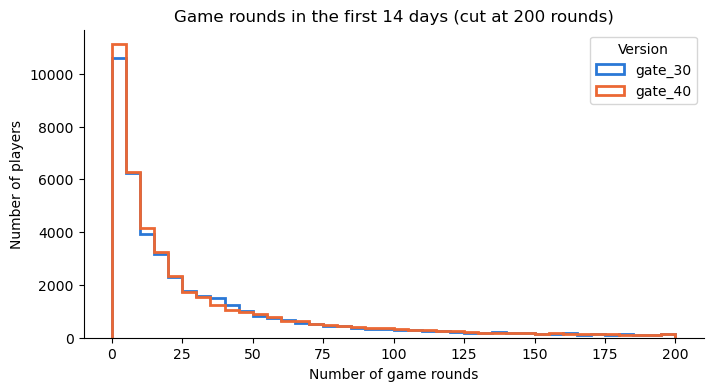

In [13]:
fig, ax = plt.subplots()
for version, colour in VERSION_COLOURS.items():
    rounds = cookie_clean.loc[cookie_clean["version"] == version, "sum_gamerounds"]
    ax.hist(rounds, bins=np.arange(0, 201, 5), color=colour, histtype="step", linewidth=2, label=version)
ax.set_title("Game rounds in the first 14 days (cut at 200 rounds)")
ax.set_xlabel("Number of game rounds")
ax.set_ylabel("Number of players")
ax.legend(title="Version")
plt.show()

In [14]:
print(f"Players who installed but never played a round: {(cookie_clean['sum_gamerounds'] == 0).mean():.1%}")
print(f"Players who played fewer than 30 rounds       : {(cookie_clean['sum_gamerounds'] < 30).mean():.1%}")

Players who installed but never played a round: 4.4%
Players who played fewer than 30 rounds       : 63.1%


The distribution is extremely right-skewed (like the Pareto example in statistics notebook 08): most players play a few rounds and quit, a few play hundreds. The two versions overlap almost perfectly.

An important detail: **about 63% of players played fewer than 30 rounds**. Many of them never even reached level 30, so they never saw either gate. For them, the two versions are identical. This **dilutes** the effect: any difference between the groups comes only from the players who got far enough. Keep this in mind when the effect looks small.

### Engagement bands (side by side)

To make the comparison easy for non-technical people, we can group players into engagement bands and compare the two versions side by side.

In [15]:
# docs: https://pandas.pydata.org/docs/reference/api/pandas.cut.html
bands = pd.cut(
    cookie_clean["sum_gamerounds"],
    bins=[-1, 0, 10, 30, 100, np.inf],
    labels=["0", "1-10", "11-30", "31-100", "100+"],
)
# docs: https://pandas.pydata.org/docs/reference/api/pandas.crosstab.html
band_share = pd.crosstab(bands, cookie_clean["version"], normalize="columns") * 100
band_share.round(1)

version,gate_30,gate_40
sum_gamerounds,,
0,4.3,4.5
1-10,35.2,35.7
11-30,23.9,24.0
31-100,23.0,21.9
100+,13.6,13.8


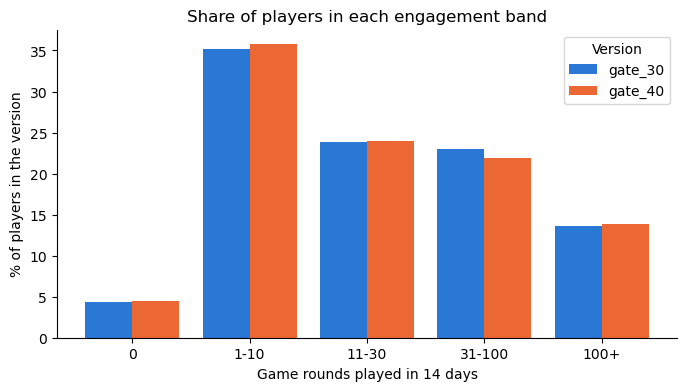

In [16]:
fig, ax = plt.subplots()
positions = np.arange(len(band_share))
ax.bar(positions - 0.2, band_share["gate_30"], width=0.4, color=BLUE, label="gate_30")
ax.bar(positions + 0.2, band_share["gate_40"], width=0.4, color=ORANGE, label="gate_40")
ax.set_xticks(positions)
ax.set_xticklabels(band_share.index)
ax.set_title("Share of players in each engagement band")
ax.set_xlabel("Game rounds played in 14 days")
ax.set_ylabel("% of players in the version")
ax.legend(title="Version")
plt.show()

The two versions have almost the same engagement profile. The only visible gap is in the 31-100 band, where gate_30 has about 1 point more players. If the gate change had a big effect on how much people play, we would see the bars shift a lot more.

### Do more rounds mean better retention?

In [17]:
retention_by_band = cookie_clean.groupby(bands, observed=True)[["retention_1", "retention_7"]].mean() * 100
retention_by_band.round(1)

,retention_1,retention_7
sum_gamerounds,,
0,2.2,0.7
1-10,12.5,1.9
11-30,45.5,8.2
31-100,74.7,27.3
100+,90.0,71.3


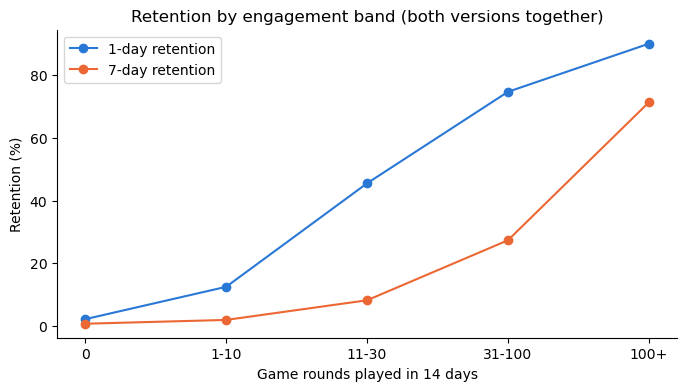

In [18]:
fig, ax = plt.subplots()
ax.plot(retention_by_band.index.astype(str), retention_by_band["retention_1"], marker="o", color=BLUE, label="1-day retention")
ax.plot(retention_by_band.index.astype(str), retention_by_band["retention_7"], marker="o", color=ORANGE, label="7-day retention")
ax.set_title("Retention by engagement band (both versions together)")
ax.set_xlabel("Game rounds played in 14 days")
ax.set_ylabel("Retention (%)")
ax.legend()
plt.show()

A very strong relationship: players with 100+ rounds have over 70% 7-day retention, players with 1-10 rounds have about 2%. Careful with the direction though: this does **not** mean "make people play more rounds and they will stay". People who like the game play more **and** come back, both because they like it. And since `sum_gamerounds` covers 14 days, it partly *includes* the coming back. This is correlation, not causation. Only the random A/B split gives us a causal answer.

---
## Summary of part 1

| Step | Result |
|---|---|
| Business question | Does moving the first gate from level 30 to 40 change retention? |
| Primary metric | 7-day retention |
| Hypotheses | H₀: no difference. H₁: some difference. α = 0.05, two-tailed |
| Sample size | About 23,600 per group for a 1-point MDE. We have about 45,000, enough to detect roughly 0.75 points |
| Duplicates / missing | None, $\color{green}{\text{passed}}$ |
| Sample ratio | 49.6% / 50.4%, chi-square p ≈ 0.009, $\color{red}{\text{warning}}$, noted as a limitation |
| Outliers | 1 impossible player (49,854 rounds) removed |
| First look | Retention slightly lower for gate_40, engagement profile almost identical |

## What's next

In **02 · A/B Testing, Part 2** we test whether the retention difference is real, put a confidence interval on it, check it with a bootstrap, look at the secondary metrics, make a decision, and walk through the classic A/B testing mistakes (peeking, multiple comparisons, novelty effects) with simulations.

## References and further reading

- Kohavi, Tang & Xu (2020), *Trustworthy Online Controlled Experiments: A Practical Guide to A/B Testing*, Cambridge University Press
- Fabijan et al. (2019), [Diagnosing Sample Ratio Mismatch in Online Controlled Experiments](https://doi.org/10.1145/3292500.3330722)
- [Cookie Cats dataset on Kaggle](https://www.kaggle.com/datasets/yufengsui/mobile-games-ab-testing)
- [statsmodels `NormalIndPower`](https://www.statsmodels.org/stable/generated/statsmodels.stats.power.NormalIndPower.html) · [Evan Miller's sample size calculator](https://www.evanmiller.org/ab-testing/sample-size.html)